In [1]:
import numpy as np
import os, sys 
import re
import ROOT
ROOT.gStyle.SetOptStat(0)
import array
from cats.cdataframe import CDataFrame
import glob

import matplotlib.pyplot as plt
from linearization import linearization
import read_relcal
%matplotlib inline

Welcome to JupyROOT 6.28/10


In [2]:
# Z1 low bg 50V
series_list=['23240109_075338', '23240109_021236', 
'23240108_203134', '23231221_101235', 
'23231221_015705', '23231220_190923', 
'23231220_122140', '23231220_053358', 
'23231220_012745', '23231219_184002', 
'23231219_110331', '23231219_034952', 
'23231218_223530', '23231218_190035', 
'23231218_152721', '23231218_093255', 
'23231218_024511', '23231217_212512', 
'23231217_171613', '23231217_135018', 
'23231216_233807', '23231216_211119', 
'23231216_194929', '23231216_182937', 
'23231216_173436', '23231216_145300', 
'23231216_100125', '23231216_043946', '23231216_013604']
ProdTag = 'CUTE_T3GeCalib_NxM_P4.0.0_V05-06_C0.3.6'

In [3]:
relative_calibration_path = {'sim': "/scratch/perry/processing/cdmsbats_config/UserSettings/BatRootSettings/analysis/DMCData.HV100mm_uni_triangle",
                             'data': "/scratch/perry/processing/cdmsbats_config/UserSettings/BatRootSettings/analysis/configCUTEData.NxM.50VZ1Z30VZ6.V4.0.0"}
RQfiles = {'sim': glob.glob("/project/6049244/share/SimData/DMC_SNOLAB_HV/Ge71_Kshell_pos50V_100kEvents_V05-09/Processed/R?/Unmerged/5125????_000000/Test_5125????_000000_F0???.root")[:80] +
                  glob.glob("/project/6049244/share/SimData/DMC_SNOLAB_HV/Ge71_Lshell_pos50V_V05-09/Processed/Unmerged/5125????_000000/Test_5125????_000000_F0???.root")[:100] + 
                  glob.glob("/project/6049244/share/SimData/DMC_SNOLAB_HV/Ge71_Mshell_pos50V_V05-09/Processed/Unmerged/5125????_000000/Test_5125????_000000_F0???.root"),
           'data': [f'/scratch/perry/CDMS/CUTE/R37/Processed/Releases/{ProdTag}/Submerged/{ProdTag}_{i}.root' for i in series_list]}
det = {'sim': 1, 'data': 1}
trigdet = {'sim': 0, 'data': 1}

In [4]:
channels = [f"P{letter}S{side}" for side in [1, 2] for letter in ["A", "B", "C", "D", "E", "F"]]
RQ_branches = ["SeriesNumber", "EventNumber", "PTOFamps", "EventTriggerID"] + [chan + "OFamps" for chan in channels]
keVt2keVee = 1/(1 + 50/3) # inverse of Luke gain factor
lin2keVee = {'sim': 210e2 * keVt2keVee, 'data': 210e2 * keVt2keVee} # (keVt/linAmp) * (keVee / keVt)
RQs = {}

## load relevant RQs
for datatype in list(RQfiles.keys()):
    df = CDataFrame("rqDir/zip"+str(det[datatype]), RQfiles[datatype], friends = [[x+":rqDir/eventTree" for x in RQfiles[datatype]]])
    
    ## Apply some basic data quality filters and get the RQs you're interested in
    df_filtered = df.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(trigdet[datatype]), "PTOFamps>0"])
    RQs[datatype] = df_filtered.AsNumpy(RQ_branches)

    # deal with CDMSSIM-451
    if datatype == 'sim':
        for branch in channels + ['PT']:
            RQs[datatype][branch + 'OFamps'] *= 10/4

    ## linearize and calibrate PTOFamps to keVee
    lin_class = linearization(det[datatype], 'PTOFamps', 'unbinned')
    RQs[datatype]['lin_PTOFamps'] = lin_class.linearize(RQs[datatype]['PTOFamps'])
    RQs[datatype]['calib_PTOFamps'] = RQs[datatype]['lin_PTOFamps'] * lin2keVee[datatype]

In [5]:
## Calculate radial parameter from channel amplitudes
for datatype in list(RQfiles.keys()):
    rel_calibs = read_relcal.get_rel_calib(relative_calibration_path[datatype])
    Fsum = RQs[datatype]['PFS1OFamps']*rel_calibs[det[datatype]]['PFS1'] + RQs[datatype]['PFS2OFamps']*rel_calibs[det[datatype]]['PFS2']
    Asum = RQs[datatype]['PAS1OFamps']*rel_calibs[det[datatype]]['PAS1'] + RQs[datatype]['PAS2OFamps']*rel_calibs[det[datatype]]['PAS2']
    RQs[datatype]['RadialPar'] = (Fsum - Asum) / RQs[datatype]['PTOFamps']

Warning in <TROOT::Append>: Replacing existing TH1: h_inset (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_inset (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_inset (Potential memory leak).


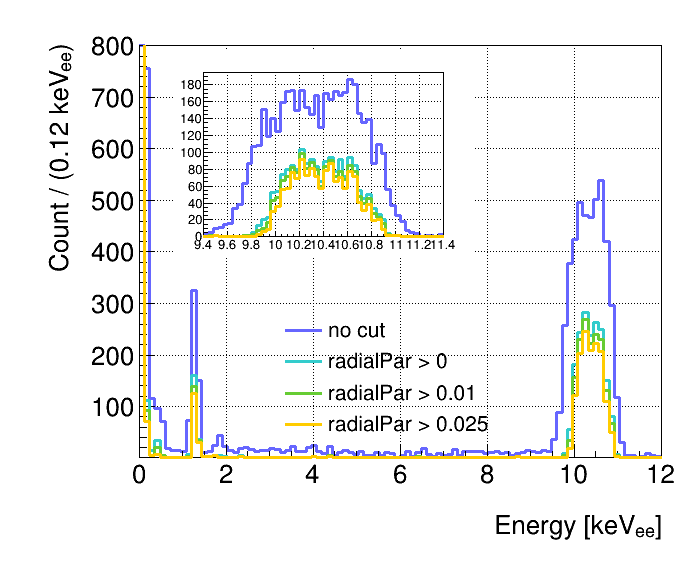

In [6]:
bins_start = 0
bins_end = 12
nbins = 100
bindiff = np.round((bins_end - bins_start) / nbins, 3)

c = ROOT.TCanvas("c", "Canvas", 700, 600)

h1 = ROOT.TH1F("h1", " ;Energy [keV_{#kern[-0.3pt]{#lower[-0.5pt]{ee}}}];Count / (" + str(bindiff) + " keV_{#kern[-0.5pt]{#lower[-0.5pt]{ee}}})", nbins, bins_start, bins_end)
data1 = RQs['data']['calib_PTOFamps']

for value in data1: h1.Fill(value)
h1.SetLineWidth(3)
h1.SetLineColor(ROOT.kBlue-7)

h2 = ROOT.TH1F("h2", f"; ; ", nbins, bins_start, bins_end)
data2 = RQs['data']['calib_PTOFamps'][RQs['data']['RadialPar'] > 0]

for value in data2: h2.Fill(value)
h2.SetLineWidth(3)
h2.SetLineColor(ROOT.kCyan-3)

h3 = ROOT.TH1F("h3", f"; ; ", nbins, bins_start, bins_end)
data3 = RQs['data']['calib_PTOFamps'][RQs['data']['RadialPar'] > 0.01]

for value in data3: h3.Fill(value)
h3.SetLineWidth(3)
h3.SetLineColor(ROOT.kSpring-5)

h4 = ROOT.TH1F("h4", f"; ; ", nbins, bins_start, bins_end)
data4 = RQs['data']['calib_PTOFamps'][RQs['data']['RadialPar'] > 0.025]

for value in data4: h4.Fill(value)
h4.SetLineWidth(3)
h4.SetLineColor(ROOT.kOrange)
    
h1.SetMinimum(1)
h1.SetMaximum(800)
h1.GetXaxis().SetLabelSize(0.05)
h1.GetYaxis().SetLabelSize(0.05)
h1.GetXaxis().SetTitleSize(0.05)
h1.GetXaxis().SetTitleOffset(1.5)
h1.GetYaxis().SetTitleSize(0.05)

legend = ROOT.TLegend(0.4, 0.23, 0.69, 0.45)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(h1, "no cut", "l")
legend.AddEntry(h2, "radialPar > 0", "l")
legend.AddEntry(h3, "radialPar > 0.01", "l")
legend.AddEntry(h4, "radialPar > 0.025", "l")
legend.SetTextSize(0.04)

c.SetLeftMargin(0.2)
c.SetBottomMargin(0.2)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
h1.Draw()
h2.Draw("SAME")
h3.Draw("SAME")
h4.Draw("SAME")

inset = ROOT.TPad("inset", "Inset Pad", 0.25, 0.55, 0.68, 0.91)
inset.SetFillColor(0)
inset.SetLineColor(1)
inset.SetBorderMode(0)
inset.Draw()
inset.cd()

inset.SetGrid(1,1)

h1_inset = ROOT.TH1F("h_inset", "", 50, 9.4, 11.4)
for value in data1: h1_inset.Fill(value)
h1_inset.SetLineWidth(3)
h1_inset.SetLineColor(ROOT.kBlue-7)

h2_inset = ROOT.TH1F("h_inset", "", 50, 9.4, 11.4)
for value in data2: h2_inset.Fill(value)
h2_inset.SetLineWidth(3)
h2_inset.SetLineColor(ROOT.kCyan-3)

h3_inset = ROOT.TH1F("h_inset", "", 50, 9.4, 11.4)
for value in data3: h3_inset.Fill(value)
h3_inset.SetLineWidth(3)
h3_inset.SetLineColor(ROOT.kSpring-5)

h4_inset = ROOT.TH1F("h_inset", "", 50, 9.4, 11.4)
for value in data4: h4_inset.Fill(value)
h4_inset.SetLineWidth(3)
h4_inset.SetLineColor(ROOT.kOrange)

h1_inset.Draw()
h2_inset.Draw("SAME")
h3_inset.Draw("SAME")
h4_inset.Draw("SAME")

h1_inset.GetXaxis().SetLabelSize(0.07)
h1_inset.GetYaxis().SetLabelSize(0.07)
h1_inset.GetXaxis().SetTitleSize(0.07)
h1_inset.GetYaxis().SetTitleSize(0.07)

c.cd()

legend.Draw()
c.SetGrid(1,1)
c.Update()
c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h2 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h3 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h4 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_inset (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_inset (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_inset (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_inset (Potential memory leak).


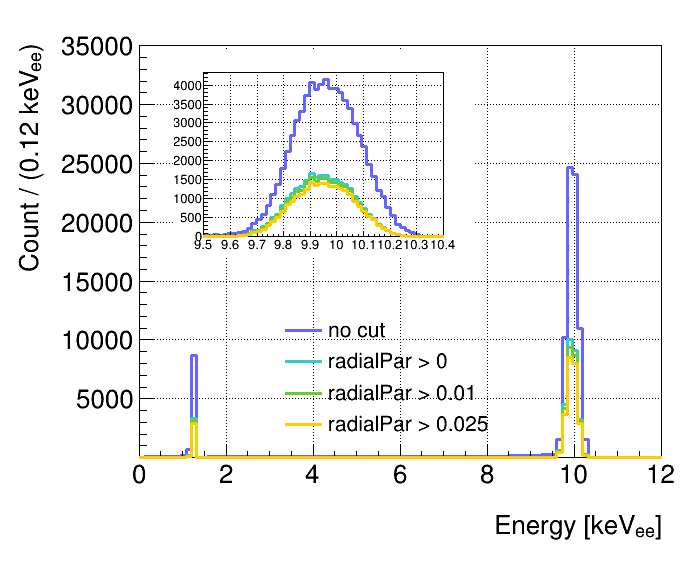

In [7]:
bins_start = 0
bins_end = 12
nbins = 100
bindiff = np.round((bins_end - bins_start) / nbins, 3)

c = ROOT.TCanvas("c", "Canvas", 700, 600)

h1 = ROOT.TH1F("h1", " ;Energy [keV_{#kern[-0.3pt]{#lower[-0.5pt]{ee}}}];Count / (" + str(bindiff) + " keV_{#kern[-0.5pt]{#lower[-0.5pt]{ee}}})", nbins, bins_start, bins_end)
data1 = RQs['sim']['calib_PTOFamps']

for value in data1: h1.Fill(value)
h1.SetLineWidth(3)
h1.SetLineColor(ROOT.kBlue-7)

h2 = ROOT.TH1F("h2", f"; ; ", nbins, bins_start, bins_end)
data2 = RQs['sim']['calib_PTOFamps'][RQs['sim']['RadialPar'] > 0]

for value in data2: h2.Fill(value)
h2.SetLineWidth(3)
h2.SetLineColor(ROOT.kCyan-3)

h3 = ROOT.TH1F("h3", f"; ; ", nbins, bins_start, bins_end)
data3 = RQs['sim']['calib_PTOFamps'][RQs['sim']['RadialPar'] > 0.01]

for value in data3: h3.Fill(value)
h3.SetLineWidth(3)
h3.SetLineColor(ROOT.kSpring-5)

h4 = ROOT.TH1F("h4", f"; ; ", nbins, bins_start, bins_end)
data4 = RQs['sim']['calib_PTOFamps'][RQs['sim']['RadialPar'] > 0.025]

for value in data4: h4.Fill(value)
h4.SetLineWidth(3)
h4.SetLineColor(ROOT.kOrange)
    
h1.SetMinimum(1)
h1.SetMaximum(35000)
h1.GetXaxis().SetLabelSize(0.05)
h1.GetYaxis().SetLabelSize(0.05)
h1.GetXaxis().SetTitleSize(0.05)
h1.GetXaxis().SetTitleOffset(1.5)
h1.GetYaxis().SetTitleSize(0.05)

legend = ROOT.TLegend(0.4, 0.23, 0.69, 0.45)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(h1, "no cut", "l")
legend.AddEntry(h2, "radialPar > 0", "l")
legend.AddEntry(h3, "radialPar > 0.01", "l")
legend.AddEntry(h4, "radialPar > 0.025", "l")
legend.SetTextSize(0.04)

c.SetLeftMargin(0.2)
c.SetBottomMargin(0.2)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
h1.Draw()
h2.Draw("SAME")
h3.Draw("SAME")
h4.Draw("SAME")

inset = ROOT.TPad("inset", "Inset Pad", 0.25, 0.55, 0.68, 0.91)
inset.SetFillColor(0)
inset.SetLineColor(1)
inset.SetBorderMode(0)
inset.Draw()
inset.cd()

inset.SetGrid(1,1)

h1_inset = ROOT.TH1F("h_inset", "", 50, 9.5, 10.4)
for value in data1: h1_inset.Fill(value)
h1_inset.SetLineWidth(3)
h1_inset.SetLineColor(ROOT.kBlue-7)

h2_inset = ROOT.TH1F("h_inset", "", 50, 9.5, 10.4)
for value in data2: h2_inset.Fill(value)
h2_inset.SetLineWidth(3)
h2_inset.SetLineColor(ROOT.kCyan-3)

h3_inset = ROOT.TH1F("h_inset", "", 50, 9.5, 10.4)
for value in data3: h3_inset.Fill(value)
h3_inset.SetLineWidth(3)
h3_inset.SetLineColor(ROOT.kSpring-5)

h4_inset = ROOT.TH1F("h_inset", "", 50, 9.5, 10.4)
for value in data4: h4_inset.Fill(value)
h4_inset.SetLineWidth(3)
h4_inset.SetLineColor(ROOT.kOrange)

h1_inset.Draw()
h2_inset.Draw("SAME")
h3_inset.Draw("SAME")
h4_inset.Draw("SAME")

h1_inset.GetXaxis().SetLabelSize(0.07)
h1_inset.GetYaxis().SetLabelSize(0.07)
h1_inset.GetXaxis().SetTitleSize(0.07)
h1_inset.GetYaxis().SetTitleSize(0.07)

c.cd()

legend.Draw()
c.SetGrid(1,1)
c.Update()
c.Draw()

/tmp/ipykernel_3748677/204883379.py:9: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  for passed, energy in zip(RQs['sim']['RadialPar'] > 0.025, RQs['sim']['calib_PTOFamps'], strict=True): eff_sim.Fill(passed, energy)
/tmp/ipykernel_3748677/204883379.py:10: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  for passed, energy in zip(RQs['data']['RadialPar'] > 0.025, RQs['data']['calib_PTOFamps'], strict=True): eff_data.Fill(passed, energy)


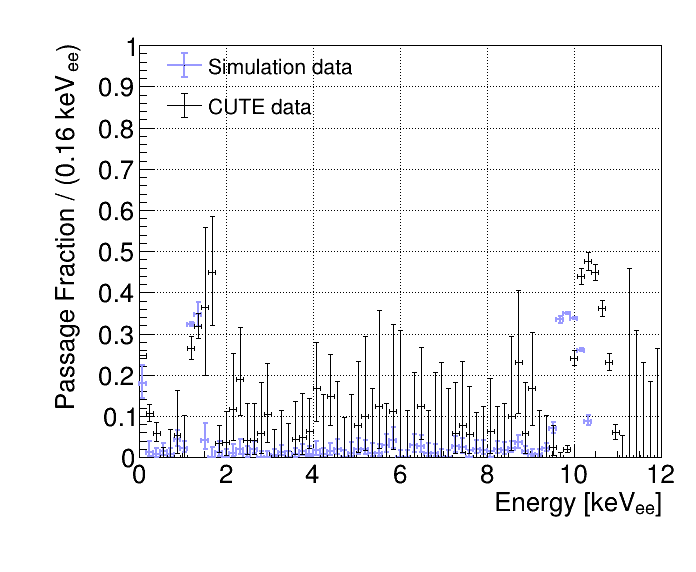

In [8]:
c = ROOT.TCanvas("c_eff", "", 700, 600)
bins_start = 0
bins_end = 12
nbins = 75
bindiff = np.round((bins_end - bins_start) / nbins, 2)

eff_sim = ROOT.TEfficiency("eff_sim", " ; ; ", nbins, bins_start, bins_end)
eff_data = ROOT.TEfficiency("eff_data", " ; ; ", nbins, bins_start, bins_end)
for passed, energy in zip(RQs['sim']['RadialPar'] > 0.025, RQs['sim']['calib_PTOFamps'], strict=True): eff_sim.Fill(passed, energy)
for passed, energy in zip(RQs['data']['RadialPar'] > 0.025, RQs['data']['calib_PTOFamps'], strict=True): eff_data.Fill(passed, energy)

g1 = eff_sim.CreateGraph()
g1.SetLineColor(ROOT.kBlue-9)
g1.SetLineWidth(2)
g1.GetXaxis().SetTitle("Energy [keV_{#kern[-0.3pt]{#lower[-0.5pt]{ee}}}]")
g1.GetYaxis().SetTitle(f"Passage Fraction / (" + str(bindiff) + " keV_{#kern[-0.5pt]{#lower[-0.5pt]{ee}}})")
g1.GetXaxis().SetLabelSize(0.05)
g1.GetYaxis().SetLabelSize(0.05)
g1.GetXaxis().SetTitleSize(0.05)
g1.GetYaxis().SetTitleSize(0.05)
g1.GetXaxis().SetLimits(bins_start, bins_end)
g1.SetMaximum(1)

g2 = eff_data.CreateGraph()
g2.SetLineColor(ROOT.kBlack)
g2.SetLineWidth(1)

legend = ROOT.TLegend(0.23, 0.78, 0.51, 0.92)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(g1, "Simulation data", "lep")
legend.AddEntry(g2, "CUTE data", "lep")
legend.SetTextSize(0.04)

g1.Draw("AP")
g2.Draw("P SAME")
legend.Draw()
c.SetLeftMargin(0.2)
c.SetBottomMargin(0.2)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
c.SetGrid(1, 1)
c.Draw()

/tmp/ipykernel_3748677/3365187872.py:9: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  for passed, energy in zip(RQs['sim']['RadialPar'] > 0.025, RQs['sim']['calib_PTOFamps'], strict=True): eff_sim.Fill(passed, energy)
/tmp/ipykernel_3748677/3365187872.py:10: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  for passed, energy in zip(RQs['data']['RadialPar'] > 0.025, RQs['data']['calib_PTOFamps'], strict=True): eff_data.Fill(passed, energy)
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_eff


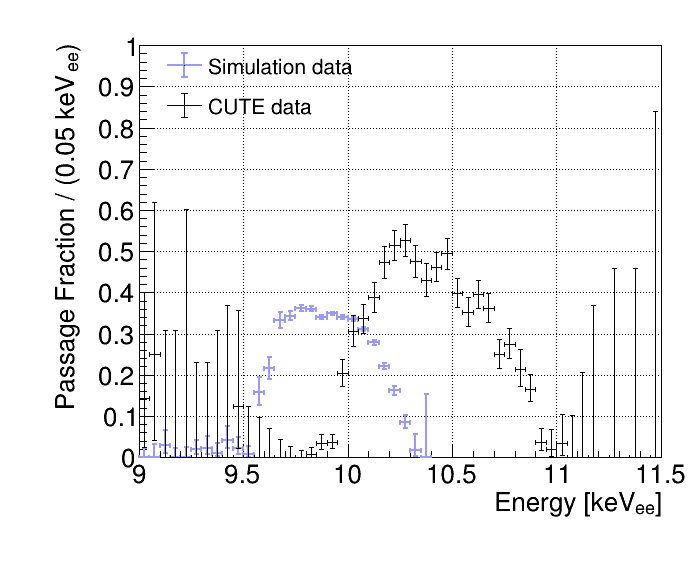

In [9]:
c = ROOT.TCanvas("c_eff", "", 700, 600)
bins_start = 9
bins_end = 11.5
nbins = 50
bindiff = np.round((bins_end - bins_start) / nbins, 2)

eff_sim = ROOT.TEfficiency("eff_sim", " ; ; ", nbins, bins_start, bins_end)
eff_data = ROOT.TEfficiency("eff_data", " ; ; ", nbins, bins_start, bins_end)
for passed, energy in zip(RQs['sim']['RadialPar'] > 0.025, RQs['sim']['calib_PTOFamps'], strict=True): eff_sim.Fill(passed, energy)
for passed, energy in zip(RQs['data']['RadialPar'] > 0.025, RQs['data']['calib_PTOFamps'], strict=True): eff_data.Fill(passed, energy)

g1 = eff_sim.CreateGraph()
g1.SetLineColor(ROOT.kBlue-9)
g1.SetLineWidth(2)
g1.GetXaxis().SetTitle("Energy [keV_{#kern[-0.3pt]{#lower[-0.5pt]{ee}}}]")
g1.GetYaxis().SetTitle(f"Passage Fraction / (" + str(bindiff) + " keV_{#kern[-0.5pt]{#lower[-0.5pt]{ee}}})")
g1.GetXaxis().SetLabelSize(0.05)
g1.GetYaxis().SetLabelSize(0.05)
g1.GetXaxis().SetTitleSize(0.05)
g1.GetYaxis().SetTitleSize(0.05)
g1.GetXaxis().SetLimits(bins_start, bins_end)
g1.SetMaximum(1)

g2 = eff_data.CreateGraph()
g2.SetLineColor(ROOT.kBlack)
g2.SetLineWidth(1)

g1.Draw("AP")
g2.Draw("P SAME")

legend = ROOT.TLegend(0.23, 0.78, 0.51, 0.92)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(g1, "Simulation data", "lep")
legend.AddEntry(g2, "CUTE data", "lep")
legend.SetTextSize(0.04)

legend.Draw()
c.SetLeftMargin(0.2)
c.SetBottomMargin(0.2)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
c.SetGrid(1, 1)
c.Draw()

In [10]:
sim_3sigma = (RQs['sim']['calib_PTOFamps'] < 9.9632 + 3*0.1209) & (RQs['sim']['calib_PTOFamps'] > 9.9632 - 3*0.1209)
data_3sigma = (RQs['data']['calib_PTOFamps'] < 10.63 + 3*0.2) & (RQs['data']['calib_PTOFamps'] > 10.08 - 3*0.23)

In [45]:
thresholds = np.arange(-0.3, 0.4, 0.005)
sim_Kcount = sum(sim_3sigma)
data_Kcount = sum(data_3sigma)

sim_thresh = []
data_thresh = []

for threshold in thresholds:
    sim_thresh.append(sum(sim_3sigma & (RQs['sim']['RadialPar'] > threshold)))
    data_thresh.append(sum(data_3sigma & (RQs['data']['RadialPar'] > threshold)))

(0.0, 0.7)

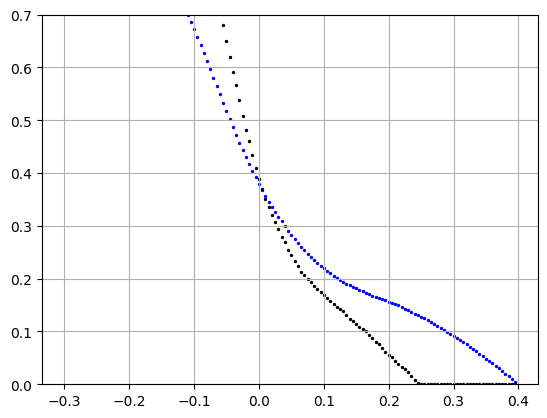

In [46]:
plt.scatter(thresholds, sim_thresh / sim_Kcount, color = 'blue', s = 2)
plt.scatter(thresholds, data_thresh / data_Kcount, color = 'black', s = 2)
plt.grid()
plt.ylim(0, 0.7)

In [47]:
sim_total = np.full_like(thresholds, sim_Kcount, dtype=int)
data_total = np.full_like(thresholds, data_Kcount, dtype=int)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_eff


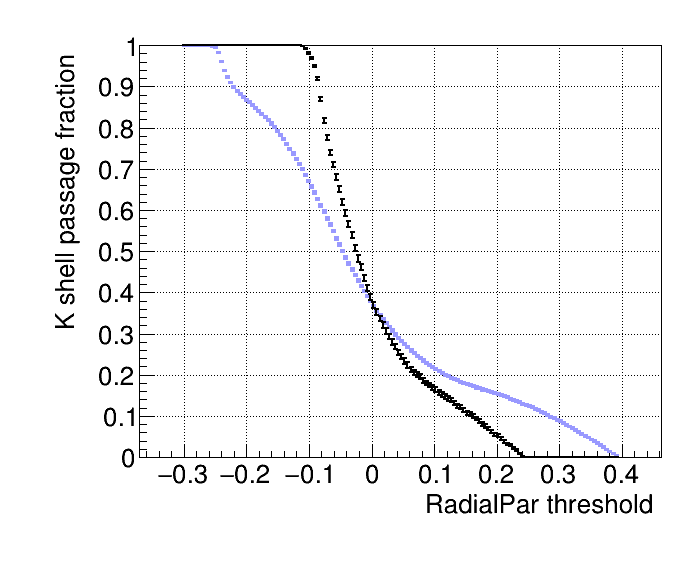

In [48]:
c = ROOT.TCanvas("c_eff", "", 700, 600)
bins_start = thresholds[0] - np.diff(thresholds)[0]/2
bins_end = thresholds[-1] - np.diff(thresholds)[0]/2
nbins = len(thresholds)
bindiff = np.round((bins_end - bins_start) / nbins, 2)

eff_sim = ROOT.TEfficiency("eff_sim", " ; ; ", nbins, bins_start, bins_end)
eff_data = ROOT.TEfficiency("eff_data", " ; ; ", nbins, bins_start, bins_end)

for i, (t, p, tot) in enumerate(zip(thresholds, sim_thresh, sim_total)):
    eff_sim.SetTotalEvents(i+1, int(tot))
    eff_sim.SetPassedEvents(i+1, int(p))

for i, (t, p, tot) in enumerate(zip(thresholds, data_thresh, data_total)):
    eff_data.SetTotalEvents(i+1, int(tot))
    eff_data.SetPassedEvents(i+1, int(p))

g1 = eff_sim.CreateGraph()
for i in range(g1.GetN()):
    g1.SetPointEXlow(i, 0)
    g1.SetPointEXhigh(i, 0)
    
g1.SetLineColor(ROOT.kBlue-9)
g1.SetLineWidth(3)
g1.GetXaxis().SetTitle("RadialPar threshold")
g1.GetYaxis().SetTitle(f"K shell passage fraction")
g1.GetXaxis().SetLabelSize(0.05)
g1.GetYaxis().SetLabelSize(0.05)
g1.GetXaxis().SetTitleSize(0.05)
g1.GetYaxis().SetTitleSize(0.05)
#g1.GetXaxis().SetLimits(bins_start, bins_end)
g1.SetMaximum(1)
g1.SetMinimum(0)

# Fit the graph
#fit_result1 = g1.Fit("pol2", "S")
#fit_func1 = g1.GetFunction("pol2")
#fit_func1.SetLineColor(ROOT.kBlue-9)
#fit_func1.SetLineStyle(3)        # 1=solid, 2=dashed, 3=dotted, ...
#fit_func1.SetLineWidth(1)
#fit_func1.SetNpx(1000)           # number of points used to draw the smooth line

# Get parameters and errors
#p0_1, p1_1, p2_1 = [fit_func1.GetParameter(i) for i in range(3)]
#e0_1, e1_1, e2_1 = [fit_func1.GetParError(i) for i in range(3)]

g2 = eff_data.CreateGraph()
for i in range(g2.GetN()):
    g2.SetPointEXlow(i, 0)
    g2.SetPointEXhigh(i, 0)
    
g2.SetLineColor(ROOT.kBlack)
g2.SetLineWidth(2)

# Fit the graph
#fit_result2 = g2.Fit("pol2", "S")
#fit_func2 = g2.GetFunction("pol2")
#fit_func2.SetLineColor(ROOT.kBlack)
#fit_func2.SetLineStyle(3)        # 1=solid, 2=dashed, 3=dotted, ...
#fit_func2.SetLineWidth(1)
#fit_func2.SetNpx(1000)           # number of points used to draw the smooth line

# Get parameters and errors
#p0_2, p1_2, p2_2 = [fit_func2.GetParameter(i) for i in range(3)]
#e0_2, e1_2, e2_2 = [fit_func2.GetParError(i) for i in range(3)]

g1.Draw("AP")
g2.Draw("P SAME")

#legend = ROOT.TLegend(0.63, 0.55, 1, 0.97)
#legend.SetBorderSize(2)
#legend.SetFillColor(0)
#legend.AddEntry(g1, "Simulation data", "ep")
#legend.AddEntry(fit_func1, "y_{sim} = p_{0} + p_{1} x + p_{2} x^{2}", "l")
#legend.AddEntry(0, "p_{0} = " + f"{p0_1:.3f} #pm {e0_1:.3f}", "")
#legend.AddEntry(0, "p_{1} = " + f"{p1_1:.2f} #pm {e1_1:.2f}", "")
#legend.AddEntry(0, "p_{2} = " + f"{p2_1:.0f} #pm {e2_1:.0f}", "")
#legend.AddEntry(g2, "CUTE data", "ep")
#legend.AddEntry(fit_func2, "y_{data} = p_{0} + p_{1} x + p_{2} x^{2}", "l")
#legend.AddEntry(0, "p_{0} = " + f"{p0_2:.3f} #pm {e0_2:.3f}", "")
#legend.AddEntry(0, "p_{1} = " + f"{p1_2:.1f} #pm {e1_2:.1f}", "")
#legend.AddEntry(0, "p_{2} = " + f"{p2_2:.0f} #pm {e2_2:.0f}", "")
#legend.SetTextSize(0.03)

#legend.Draw()
c.SetLeftMargin(0.2)
c.SetBottomMargin(0.2)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
c.SetGrid(1, 1)
c.Draw()